# 期末作业 [简单]：CNN模型与FashionMNIST分类

### 作业目标：
1.  掌握使用 `torchvision.datasets` 加载标准数据集（FashionMNIST）。
2.  学会构建一个基础的卷积神经网络（CNN）。
3.  掌握完整的模型训练与测试流程。
4.  学会使用 `matplotlib` 绘制损失或准确率曲线。

### 作业背景：
FashionMNIST 是一个替代 MNIST 的图像数据集。它同样包含 60,000 张训练图像和 10,000 张测试图像，每张都是 28x28 的灰度图，但分为了10个时尚单品类别（T-shirt, Trouser, Pullover...）。它比 MNIST 更能检验模型的真实性能。

### 教学参考：
本项目主要参考 `05_multi_classes_gpu.py` (MLP) 和 `06_cnn.py` (CNN) 脚本的结构。

## 1. 准备工作：导入库与设置设备

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# TODO: 设置 device，优先使用 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. 数据加载与预处理

你需要：
1.  定义 `transforms`，至少包含 `ToTensor()` 和 `Normalize()`。
2.  使用 `datasets.FashionMNIST` 加载训练集和测试集。
3.  创建 `DataLoader`。

In [2]:
# 定义超参数
batch_size = 64
learning_rate = 0.001
epochs = 50

# TODO: 定义数据预处理
# FashionMNIST 的均值和标准差是 (0.1307,), (0.3081,)，和MNIST相同
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# TODO: 加载 FashionMNIST 训练集和测试集
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# TODO: 创建 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print(f"Loaded {len(train_dataset)} training images and {len(test_dataset)} test images.")

Loaded 60000 training images and 10000 test images.


## 3. 构建CNN模型

请构建一个简单的CNN模型。你可以参考 `06_cnn.py` 的结构，但也可以自由发挥。
一个推荐的结构：
1.  `Conv2d` (输入通道 1, 输出通道 10, kernel_size 5)
2.  `MaxPool2d` (kernel_size 2)
3.  `ReLU`
4.  `Conv2d` (输入通道 10, 输出通道 20, kernel_size 5)
5.  `MaxPool2d` (kernel_size 2)
6.  `ReLU`
7.  展平 (`view` 或 `flatten`)
8.  `Linear` (输入维度需自己计算，输出维度 10)

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # TODO: 定义你的网络层

        # 输入是 28x28 -> conv1(5) -> 24x24 -> pool(2) -> 12x12
        # -> conv2(5) -> 8x8 -> pool(2) -> 4x4
        # 展平后的大小 = 20 * 4 * 4 = 320
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5)
        self.fc1 = nn.Linear(20 * 4 * 4, 10)


    def forward(self, x):
        # TODO: 定义前向传播逻辑
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        # 展平
        x = torch.flatten(x, start_dim=1)
        x = self.fc1(x)
        
        # 交叉熵损失函数前不需要 Softmax
        return x

# TODO: 实例化模型并将其移动到 device
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=320, out_features=10, bias=True)
)


## 4. 定义损失函数和优化器

对于多分类问题，我们使用：
1.  损失函数：`nn.CrossEntropyLoss`
2.  优化器：`optim.SGD` 或 `optim.Adam`

In [4]:
# TODO: 定义损失函数
criterion = criterion = nn.CrossEntropyLoss()

# TODO: 定义优化器
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

## 5. 训练与测试函数

In [5]:
def train(epoch, log_interval=200):
    model.train() # 设置为训练模式
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        # TODO: 将数据移动到 device
        data = data.to(device)
        target = target.to(device)
        
        # TODO: 1. 梯度清零
        optimizer.zero_grad()
        
        # TODO: 2. 前向传播
        output = model(data)
        
        # TODO: 3. 计算损失
        loss = criterion(output, target)
        
        # TODO: 4. 反向传播
        loss.backward()
        
        # TODO: 5. 更新参数
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % log_interval == log_interval - 1:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ' 
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {running_loss / log_interval:.6f}')
            running_loss = 0.0
    return running_loss / len(train_loader) # 返回平均损失

def test():
    model.eval() # 设置为评估模式
    test_loss = 0
    correct = 0
    with torch.no_grad(): # 在评估时关闭梯度计算
        for data, target in test_loader:
            # TODO: 将数据移动到 device
            data = data.to(device)
            target = target.to(device)
            
            # TODO: 1. 前向传播
            output = model(data)
            
            # TODO: 2. 累计测试损失
            test_loss += criterion(output, target).item() * data.size(0)
            
            # TODO: 3. 找到概率最高的类别
            # torch.max 返回 (values, indices)，我们取 indices
            _, pred = torch.max(output, dim=1)
            
            # TODO: 4. 累计正确预测的数量
            correct += pred.eq(target).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ' 
          f'({accuracy:.2f}%)\n')
    return test_loss, accuracy

## 6. 执行训练与评估

我们将循环 `epochs` 次，记录每次的损失和准确率，用于后续绘图。

In [6]:
train_losses = []
test_losses = []
test_accuracies = []

print("Start Training...")
for epoch in range(1, epochs + 1):
    train_loss = train(epoch)
    test_loss, test_acc = test()
    
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
print("Finished Training.")

Start Training...
Train Epoch: 1 [12736/60000 (21%)]	Loss: 0.876304
Train Epoch: 1 [25536/60000 (43%)]	Loss: 0.536864
Train Epoch: 1 [38336/60000 (64%)]	Loss: 0.477232
Train Epoch: 1 [51136/60000 (85%)]	Loss: 0.429156

Test set: Average loss: 0.4373, Accuracy: 8469/10000 (84.69%)

Train Epoch: 2 [12736/60000 (21%)]	Loss: 0.410029
Train Epoch: 2 [25536/60000 (43%)]	Loss: 0.383188
Train Epoch: 2 [38336/60000 (64%)]	Loss: 0.381109
Train Epoch: 2 [51136/60000 (85%)]	Loss: 0.360788

Test set: Average loss: 0.3836, Accuracy: 8644/10000 (86.44%)

Train Epoch: 3 [12736/60000 (21%)]	Loss: 0.347033
Train Epoch: 3 [25536/60000 (43%)]	Loss: 0.349981
Train Epoch: 3 [38336/60000 (64%)]	Loss: 0.343474
Train Epoch: 3 [51136/60000 (85%)]	Loss: 0.327272

Test set: Average loss: 0.3709, Accuracy: 8666/10000 (86.66%)

Train Epoch: 4 [12736/60000 (21%)]	Loss: 0.332700
Train Epoch: 4 [25536/60000 (43%)]	Loss: 0.323862
Train Epoch: 4 [38336/60000 (64%)]	Loss: 0.327027
Train Epoch: 4 [51136/60000 (85%)]	Loss:

## 7. 结果可视化

请绘制训练损失、测试损失和测试准确率随 Epoch 变化的曲线。

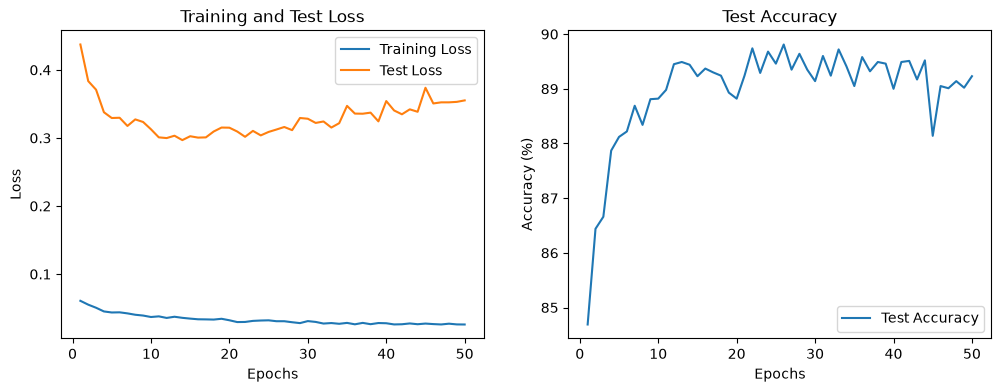

In [7]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Test Loss')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Test Accuracy')

plt.show()

## 8. 结论（选填）

请在此处写下你的结论或观察：
* 最终达到的最高准确率是多少？ 
* 模型是否出现了过拟合（训练损失持续下降，但测试损失/准确率停止改善）？
* 模型在5个epoch内能够正常收敛，最高准确率88.23%。把epoch提到50之后，发现测试损失在前期下降后并没有继续降低，反而出现上升和波动。但训练损失仍然持续下降，说明模型在训练集上继续变好，但在测试集上的泛化效果没有同步提升，出现了过拟合。